# RAMIP path-independence at a matched GWL 2.0

Everything RAMIP, redone at a **single global warming level (2.0 K above 1850–1900)** instead of the year-matched 2041–2050 window used in `ks_path_independence_ramip_multi.ipynb`.

**Why this notebook exists.** A year-matched comparison of `ssp370` against `ssp370-126aer` mixes two things: the aerosol *pattern* response, and the fact that removing aerosols warms the planet faster, so at a fixed year the two experiments sit at different global temperatures. Only the first is a violation of path-independence. Matching on GWL removes the second: each experiment is sampled in *its own* decade where its global-mean warming first reaches 2.0 K, so any remaining distributional difference is pathway-dependence at a fixed global warming level, which is exactly the question.

**Definition used here.**
- Baseline: model's own 1850–1900 mean GMST from CMIP6 `historical` (`Amon` `tas`, area-weighted, up to 3 members averaged), read from the pangeo GCS catalogue.
- GWL2.0 window for each (experiment, run) = the **first 10-year window whose running-mean GMST anomaly reaches 2.0 K**. 10 years (not the usual 20) keeps n = 120 months per sample, identical to the year-matched analysis and to the 10 annual blocks the block-permutation test resamples — the two sets of maps stay directly comparable.
- Windows are computed **per run**, not per experiment ensemble mean, following the BCD-ME convention of a per-member GWL coordinate. Each member is therefore compared to its own GWL2.0 decade.

**Known caveats, flagged in the output rather than hidden.**
- `CanESM5-1` has no `historical` on pangeo; its baseline is borrowed from its parent `CanESM5`. Reported separately below.
- Not every model reaches 2.0 K inside its available RAMIP data (several `ssp370-126aer` branches stop in 2051, and MIROC6 warms slowly enough that `ssp370` does not reach 2.0 K until the 2060s). Runs that never reach GWL2.0 in both experiments are dropped, and the drop is listed explicitly — a model surviving with fewer members is a weaker result, not a cleaner one.
- The KS test used is the **block-permutation** test whose size is verified in `ks_block_permutation.ipynb` and `ks_blockperm_diagnostics.ipynb`; the asymptotic p is computed alongside for comparison only.

In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats as sstats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cmocean
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

warnings.filterwarnings('ignore', category=FutureWarning)

RAW    = dir_list['raw'] + 'ramip/'
OTHER  = 'ssp370-126aer'
ANCHOR = {m: 'ssp370' for m in
          ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6',
           'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
ANCHOR['CESM2'] = 'ssp370-LE'      # RAMIP's CESM2 reference scenario
MODELS = sorted(ANCHOR)

GWL    = 2.0
WIN    = 10                        # years per sample -> n = 120 months
BASE   = (1850, 1900)
ALPHA  = 0.05
NDRAWS = 999
BLOCK  = 12

GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
os.makedirs(GWL_DIR, exist_ok=True)
out_dir = dir_list['aux'] + '../figures/'

# historical for CanESM5-1 is not on pangeo; its parent model stands in for the baseline
BASE_PROXY = {'CanESM5-1': 'CanESM5'}


def member_files(mod, exp):
    """run -> file. Some runs exist at several time spans (GISS, UKESM); keep the longest."""
    out = {}
    for f in sorted(glob.glob(f'{RAW}{mod}/tas_Amon_{mod}_{exp}_r*.zarr')):
        run = re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1)
        end = re.search(r'-(\d{4})\d{4}\.zarr$', f)
        end = int(end.group(1)) if end else 0
        if run not in out or end > out[run][1]:
            out[run] = (f, end)
    return {r: v[0] for r, v in out.items()}


def matched_runs(mod):
    a, b = member_files(mod, ANCHOR[mod]), member_files(mod, OTHER)
    return sorted(set(a) & set(b), key=lambda m: [int(x) for x in re.findall(r'\d+', m)]), a, b


def gmst(da):
    return da.weighted(np.cos(np.deg2rad(da.lat))).mean([d for d in da.dims if d != 'time'])


print(f'{len(MODELS)} models, GWL {GWL} K vs {BASE[0]}-{BASE[1]}, {WIN}-yr windows (n={12*WIN} months)')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


9 models, GWL 2.0 K vs 1850-1900, 10-yr windows (n=120 months)


## 1. Pre-industrial baselines from CMIP6 `historical`

Area-weighted 1850–1900 mean GMST per model, averaged over up to 3 `historical` members (a 51-year mean has very little internal variability left, so a handful of members is plenty). Read straight from the pangeo GCS zarr stores; only the 1850–1900 slice is touched.

In [2]:
BASE_FN = f'{GWL_DIR}baseline_{BASE[0]}_{BASE[1]}.csv'
NMEM_BASE = 3

if os.path.exists(BASE_FN):
    base_df = pd.read_csv(BASE_FN).set_index('model')
    print('loaded cached baselines')
else:
    cat = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
    hist = cat[(cat.experiment_id == 'historical') & (cat.table_id == 'Amon')
               & (cat.variable_id == 'tas')]
    rows = []
    for mod in MODELS:
        src = BASE_PROXY.get(mod, mod)
        sub = hist[hist.source_id == src]
        assert len(sub), f'no historical for {src}'
        vals, mems = [], []
        for _, r in sub.head(NMEM_BASE).iterrows():
            ds = xr.open_zarr(r.zstore, consolidated=True, storage_options={'token': 'anon'})
            vals.append(float(gmst(ds.tas.sel(time=slice(str(BASE[0]), str(BASE[1]))))
                              .mean('time').compute()))
            mems.append(r.member_id)
        rows.append({'model': mod, 'baseline_K': np.mean(vals), 'spread_K': np.ptp(vals),
                     'source': src, 'members': ' '.join(mems),
                     'proxy': src != mod})
        print(f'  {mod:20s} {np.mean(vals):.3f} K  (from {src}, {len(vals)} members, '
              f'spread {np.ptp(vals):.3f} K)')
    base_df = pd.DataFrame(rows).set_index('model')
    base_df.to_csv(BASE_FN)
    print('saved', BASE_FN)

base_df

  CESM2                287.168 K  (from CESM2, 3 members, spread 0.085 K)


  CNRM-ESM2-1          286.767 K  (from CNRM-ESM2-1, 3 members, spread 0.151 K)


  CanESM5-1            286.542 K  (from CanESM5, 3 members, spread 0.094 K)


  EC-Earth3-AerChem    287.348 K  (from EC-Earth3-AerChem, 2 members, spread 0.055 K)


  GISS-E2-1-G          286.920 K  (from GISS-E2-1-G, 3 members, spread 0.036 K)


  MIROC6               288.416 K  (from MIROC6, 3 members, spread 0.044 K)


  MRI-ESM2-0           286.939 K  (from MRI-ESM2-0, 3 members, spread 0.048 K)


  NorESM2-LM           287.710 K  (from NorESM2-LM, 3 members, spread 0.101 K)


  UKESM1-0-LL          286.517 K  (from UKESM1-0-LL, 3 members, spread 0.039 K)
saved /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/baseline_1850_1900.csv


,baseline_K,spread_K,source,members,proxy
model,,,,,
CESM2,287.168138,0.084569,CESM2,r1i1p1f1 r4i1p1f1 r5i1p1f1,False
CNRM-ESM2-1,286.766667,0.151160,CNRM-ESM2-1,r1i1p1f2 r3i1p1f2 r5i1p1f2,False
CanESM5-1,286.542161,0.093907,CanESM5,r11i1p1f1 r10i1p2f1 r11i1p2f1,True
EC-Earth3-AerChem,287.348407,0.054625,EC-Earth3-AerChem,r1i1p1f1 r4i1p1f1,False
GISS-E2-1-G,286.919774,0.036052,GISS-E2-1-G,r2i1p1f1 r1i1p1f1 r3i1p1f1,False
MIROC6,288.416118,0.044407,MIROC6,r8i1p1f1 r6i1p1f1 r4i1p1f1,False
MRI-ESM2-0,286.939134,0.047608,MRI-ESM2-0,r4i1p1f1 r2i1p1f1 r5i1p1f1,False
NorESM2-LM,287.710443,0.101017,NorESM2-LM,r1i1p1f1 r3i1p1f1 r2i1p1f1,False
UKESM1-0-LL,286.516560,0.038789,UKESM1-0-LL,r1i1p1f2 r3i1p1f2 r2i1p1f2,False


## 2. Annual GMST per matched run, and the GWL2.0 window

For every matched run of every model, both experiments: area-weighted annual-mean GMST minus the model baseline, then the first `WIN`-year window whose running mean reaches `GWL`. `window_end` is the last year of that window, so the sample is `window_end-9 … window_end` inclusive.

In [3]:
GMST_FN = f'{GWL_DIR}gmst_annual.nc'

if os.path.exists(GMST_FN):
    gm = xr.open_dataarray(GMST_FN).load()
    print(f'loaded cached GMST ({gm.sizes})')
else:
    per_mod = []
    for mod in MODELS:
        runs, afns, bfns = matched_runs(mod)
        b = float(base_df.loc[mod, 'baseline_K'])
        per_exp = []
        for exp, fns in [(ANCHOR[mod], afns), (OTHER, bfns)]:
            per_run = []
            for r in runs:
                ds = xr.open_zarr(fns[r], consolidated=False)
                g = gmst(ds.tas).groupby('time.year').mean().compute() - b
                per_run.append(g.assign_coords(run=r))
            per_exp.append(xr.concat(per_run, dim='run').assign_coords(arm=exp))
            print(f'  {mod} {exp}: {len(runs)} runs, '
                  f'{int(per_exp[-1].year.min())}-{int(per_exp[-1].year.max())}', flush=True)
        # 'arm' = anchor/other, since the anchor experiment name differs for CESM2
        da = xr.concat(per_exp, dim='arm').assign_coords(arm=['anchor', 'other'])
        per_mod.append(da.assign_coords(model=mod))
    gm = xr.concat(per_mod, dim='model', join='outer')
    gm.rename('gmst_anom').to_netcdf(GMST_FN)
    print('saved', GMST_FN)

  CESM2 ssp370-LE: 10 runs, 2015-2100


  CESM2 ssp370-126aer: 10 runs, 2015-2079


  CNRM-ESM2-1 ssp370: 10 runs, 2015-2100


  CNRM-ESM2-1 ssp370-126aer: 10 runs, 2015-2051


  CanESM5-1 ssp370: 10 runs, 2015-2051


...

  NorESM2-LM ssp370: 7 runs, 2015-2059


  NorESM2-LM ssp370-126aer: 7 runs, 2015-2059


  UKESM1-0-LL ssp370: 10 runs, 2015-2100


  UKESM1-0-LL ssp370-126aer: 10 runs, 2015-2100


saved /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/gmst_annual.nc


In [4]:
def gwl_window(series, gwl=GWL, win=WIN):
    """Last year of the first `win`-year window whose running-mean anomaly reaches `gwl`.
    None if the run never gets there within its available data."""
    roll = series.rolling(year=win).mean()
    ok = np.isfinite(roll.values) & (roll.values >= gwl)
    yrs = roll.year.values[ok]
    return int(yrs[0]) if yrs.size else None


rows = []
for mod in MODELS:
    g = gm.sel(model=mod)
    for r in [str(x) for x in g.run.values]:
        s = g.sel(run=r)
        if not np.isfinite(s).any():
            continue
        w = {arm: gwl_window(s.sel(arm=arm).dropna('year')) for arm in ['anchor', 'other']}
        rows.append({'model': mod, 'run': r,
                     'anchor_end': w['anchor'], 'other_end': w['other'],
                     'anchor_last_year': int(s.sel(arm='anchor').dropna('year').year.max()),
                     'other_last_year': int(s.sel(arm='other').dropna('year').year.max()),
                     'usable': w['anchor'] is not None and w['other'] is not None})
win_df = pd.DataFrame(rows)

print(f'runs reaching GWL{GWL} in BOTH experiments, per model:')
for mod in MODELS:
    s = win_df[win_df.model == mod]
    u = s[s.usable]
    if len(u):
        lag = (u.anchor_end - u.other_end)
        print(f'  {mod:20s} {len(u):2d}/{len(s):2d} usable   anchor window ends '
              f'{u.anchor_end.min()}-{u.anchor_end.max()}, {OTHER} ends '
              f'{u.other_end.min()}-{u.other_end.max()}   '
              f'({OTHER} reaches GWL{GWL} {lag.mean():.1f} yr earlier on average)')
    else:
        why = []
        if s.anchor_end.isna().all():
            why.append(f'anchor never reaches {GWL}K by {s.anchor_last_year.max()}')
        if s.other_end.isna().all():
            why.append(f'{OTHER} never reaches {GWL}K by {s.other_last_year.max()}')
        print(f'  {mod:20s}  0/{len(s):2d} usable   DROPPED: {"; ".join(why)}')

win_df.to_csv(f'{GWL_DIR}gwl{GWL}_windows.csv', index=False)
USABLE = {m: win_df[(win_df.model == m) & win_df.usable] for m in MODELS}
GWL_MODELS = [m for m in MODELS if len(USABLE[m])]
print(f'\nmodels retained: {GWL_MODELS}')

runs reaching GWL2.0 in BOTH experiments, per model:
  CESM2                10/10 usable   anchor window ends 2043.0-2049.0, ssp370-126aer ends 2036.0-2041.0   (ssp370-126aer reaches GWL2.0 8.1 yr earlier on average)
  CNRM-ESM2-1           6/10 usable   anchor window ends 2052.0-2056.0, ssp370-126aer ends 2046.0-2050.0   (ssp370-126aer reaches GWL2.0 6.2 yr earlier on average)
  CanESM5-1            10/10 usable   anchor window ends 2024.0-2029.0, ssp370-126aer ends 2024.0-2028.0   (ssp370-126aer reaches GWL2.0 0.3 yr earlier on average)
  EC-Earth3-AerChem     6/ 6 usable   anchor window ends 2037.0-2044.0, ssp370-126aer ends 2033.0-2037.0   (ssp370-126aer reaches GWL2.0 6.7 yr earlier on average)
  GISS-E2-1-G          10/10 usable   anchor window ends 2039.0-2041.0, ssp370-126aer ends 2036.0-2040.0   (ssp370-126aer reaches GWL2.0 2.5 yr earlier on average)
  MIROC6               10/10 usable   anchor window ends 2066.0-2070.0, ssp370-126aer ends 2053.0-2056.0   (ssp370-126aer reach

### GMST trajectories and the selected windows

One panel per model: running-mean GMST anomaly for both experiments (thin lines = members), the GWL2.0 line, and the selected windows shaded. Makes the aerosol-cleanup warming acceleration visible — the `ssp370-126aer` bundle sits above `ssp370` and crosses 2.0 K earlier — and shows which models simply run out of data before crossing.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ramip_gwl2.0_windows.png


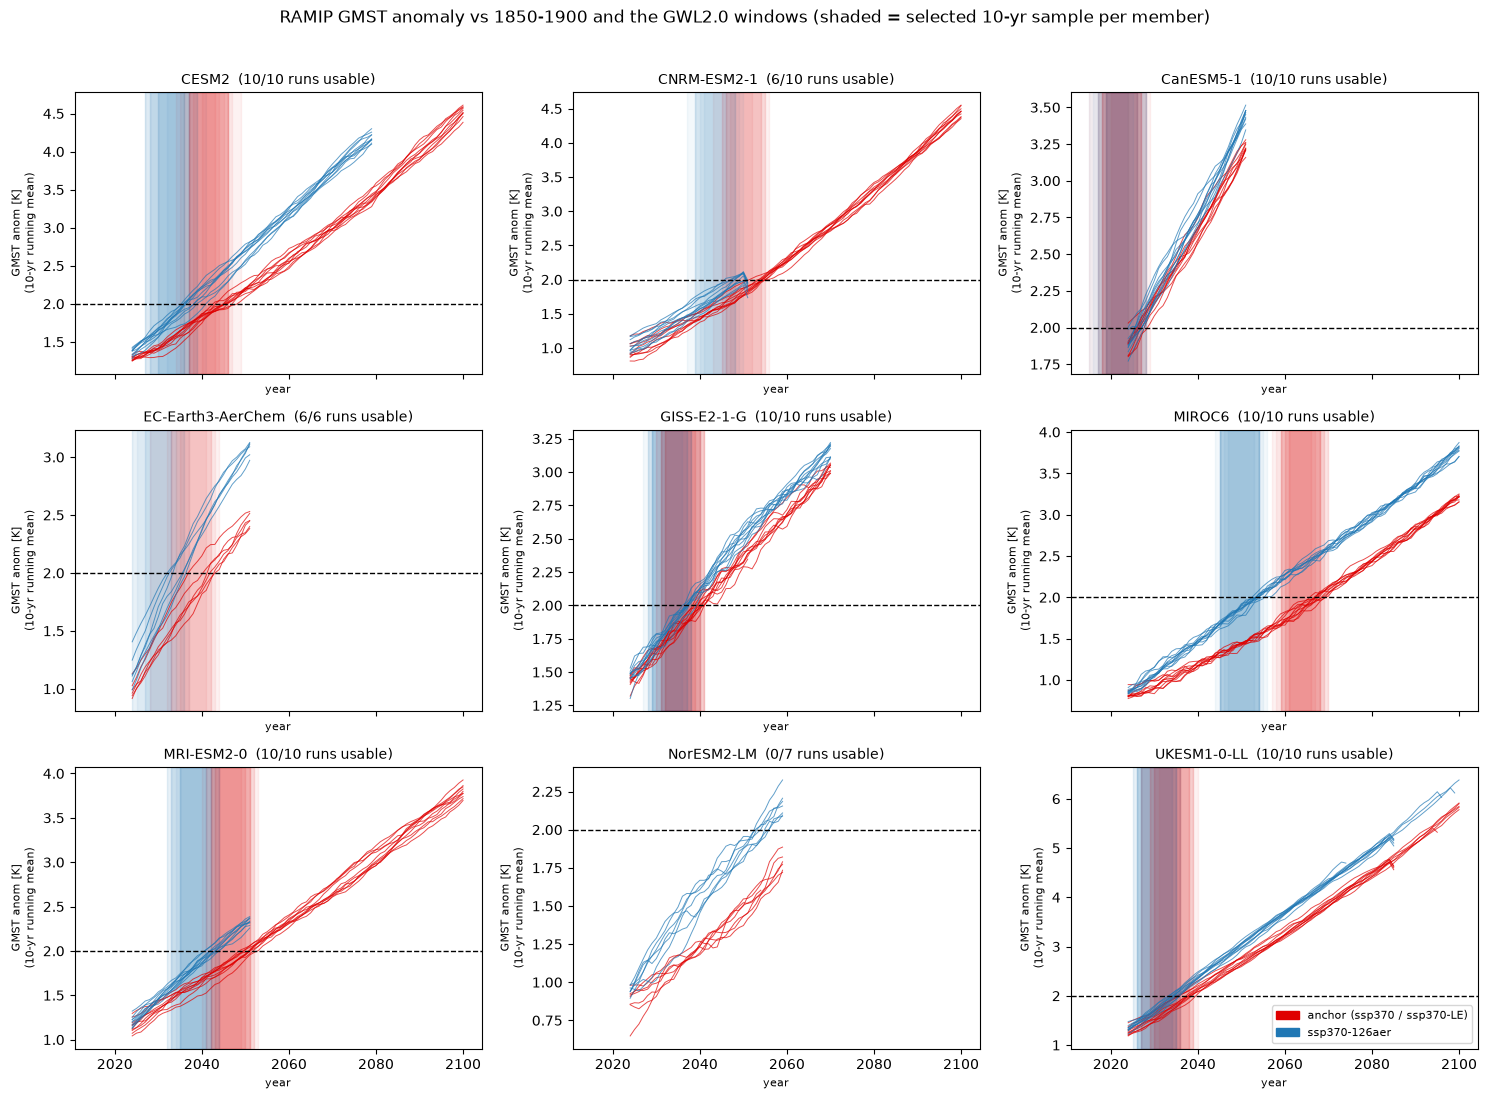

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
for ax, mod in zip(axs.flat, MODELS):
    g = gm.sel(model=mod)
    for arm, cl in [('anchor', '#df0000'), ('other', '#1f77b4')]:
        s = g.sel(arm=arm).rolling(year=WIN).mean()
        ax.plot(s.year, s.values.T, color=cl, lw=0.7, alpha=0.7)
    u = USABLE[mod]
    for _, r in u.iterrows():
        ax.axvspan(r.anchor_end - WIN + 1, r.anchor_end, color='#df0000', alpha=0.05)
        ax.axvspan(r.other_end - WIN + 1, r.other_end, color='#1f77b4', alpha=0.05)
    ax.axhline(GWL, color='k', ls='--', lw=1)
    ax.set_title(f'{mod}  ({len(u)}/{len(win_df[win_df.model == mod])} runs usable)', fontsize=10)
    ax.set_ylabel(f'GMST anom [K]\n({WIN}-yr running mean)', fontsize=8)
    ax.set_xlabel('year', fontsize=8)
ax.legend(handles=[mpatches.Patch(color='#df0000', label='anchor (ssp370 / ssp370-LE)'),
                   mpatches.Patch(color='#1f77b4', label=OTHER)], fontsize=8, loc='lower right')
fig.suptitle(f'RAMIP GMST anomaly vs {BASE[0]}-{BASE[1]} and the GWL{GWL} windows '
             f'(shaded = selected {WIN}-yr sample per member)', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(out_dir + f'ramip_gwl{GWL}_windows.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ramip_gwl{GWL}_windows.png')

## 3. Pixel-wise KS at matched GWL2.0

Same machinery as the year-matched notebook — numba `ks_statistic_sorted` from `enso_bias_impacts/code/4-fig_impact_figures.ipynb`, the block-permutation variant, `prange` over pixels — but each experiment contributes *its own* GWL2.0 decade, so the samples are matched on global warming rather than on calendar year. Asymptotic p is computed on the same windows for comparison.

In [6]:
from numba import njit, prange, set_num_threads
set_num_threads(16)


@njit
def ks_statistic_sorted(x, y):
    """KS statistic for already-sorted arrays (verbatim from 4-fig_impact_figures.ipynb)."""
    nx = len(x); ny = len(y)
    i = 0; j = 0
    cdfx = 0.0; cdfy = 0.0
    d = 0.0
    while i < nx and j < ny:
        if x[i] <= y[j]:
            i += 1
            cdfx = i / nx
        else:
            j += 1
            cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while i < nx:
        i += 1
        cdfx = i / nx
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while j < ny:
        j += 1
        cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    return d


@njit
def ks_block_permutation_test(x, y, block=12, ndraws=999):
    """Block-permutation KS p (size verified in ks_block_permutation.ipynb)."""
    nx = len(x); ny = len(y)
    nbx = nx // block; nby = ny // block
    nb = nbx + nby
    D_obs = ks_statistic_sorted(np.sort(x.copy()), np.sort(y.copy()))
    pool = np.empty(nx + ny, dtype=x.dtype)
    pool[:nx] = x
    pool[nx:] = y
    order = np.arange(nb)
    xperm = np.empty(nx, dtype=x.dtype)
    yperm = np.empty(ny, dtype=x.dtype)
    exceed = 0
    for draw in range(ndraws):
        for i in range(nb - 1, 0, -1):
            j = np.random.randint(i + 1)
            tmp = order[i]; order[i] = order[j]; order[j] = tmp
        for b in range(nbx):
            s = order[b] * block
            xperm[b * block:(b + 1) * block] = pool[s:s + block]
        for b in range(nby):
            s = order[nbx + b] * block
            yperm[b * block:(b + 1) * block] = pool[s:s + block]
        xperm.sort(); yperm.sort()
        if ks_statistic_sorted(xperm, yperm) >= D_obs:
            exceed += 1
    return (exceed + 1) / (ndraws + 1)   # Phipson & Smyth 2010


@njit(parallel=True)
def block_perm_map(A, B, block=12, ndraws=999):
    """p-value per pixel; A, B are (pixels, time)."""
    P = A.shape[0]
    out = np.empty(P)
    for px in prange(P):
        out[px] = ks_block_permutation_test(A[px], B[px], block, ndraws)
    return out


def ks_fast(a1, a2):
    """asymptotic p per pixel (as in ks_path_independence_maps.ipynb)"""
    P, n1 = a1.shape; n2 = a2.shape[1]
    z = np.concatenate([a1, a2], axis=1)
    order = np.argsort(z, axis=1, kind='stable')
    zs = np.take_along_axis(z, order, axis=1)
    ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
    cd = np.cumsum(ind, axis=1)
    valid = np.ones_like(cd, dtype=bool)
    valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
    D = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    en = int(np.round(n1 * n2 / (n1 + n2)))
    uD, inv = np.unique(D, return_inverse=True)
    return np.clip(sstats.kstwo.sf(uD, en), 0, 1)[inv]


def window_vals(fn, y_end, win=WIN):
    """monthly tas over the `win` years ending at y_end, as (pixels, months)."""
    ds = xr.open_zarr(fn, consolidated=False)
    yr = ds.time.dt.year
    da = ds['tas'].sel(time=(yr > y_end - win) & (yr <= y_end))
    v = da.load().transpose('lat', 'lon', 'time')
    return v.values.reshape(-1, v.sizes['time']), v.lat, v.lon, v.sizes['time']


_r = np.random.default_rng(0)
_x, _y = _r.standard_normal((2, 120)), _r.standard_normal((2, 120))
print('iid check  perm:', np.round(block_perm_map(_x, _y, BLOCK, NDRAWS), 3),
      ' asymptotic:', np.round(ks_fast(_x, _y), 3))

iid check  perm: [0.337 0.788]  asymptotic: [0.451 0.66 ]


In [7]:
KS_DIR = f'{GWL_DIR}ks/'
os.makedirs(KS_DIR, exist_ok=True)

results = {}
for mod in GWL_MODELS:
    cache_fn = f'{KS_DIR}{mod}.nc'
    if os.path.exists(cache_fn):
        results[mod] = xr.open_dataset(cache_fn).load()
        print(f'{mod}: loaded cache ({results[mod].sizes["run"]} runs)')
        continue
    _, afns, bfns = matched_runs(mod)
    bp, asy, runs_used = [], [], []
    for _, row in USABLE[mod].iterrows():
        va, lat, lon, n1 = window_vals(afns[row.run], int(row.anchor_end))
        vb, *_, n2      = window_vals(bfns[row.run], int(row.other_end))
        if n1 != 12 * WIN or n2 != 12 * WIN:
            print(f'  {mod} {row.run}: short window {n1}/{n2} months, skipped')
            continue
        bp.append(block_perm_map(va, vb, BLOCK, NDRAWS).reshape(len(lat), len(lon)))
        asy.append(ks_fast(va, vb).reshape(len(lat), len(lon)))
        runs_used.append(row.run)
        print(f'  {mod} {row.run}: anchor {int(row.anchor_end)-WIN+1}-{int(row.anchor_end)} '
              f'vs {OTHER} {int(row.other_end)-WIN+1}-{int(row.other_end)} done', flush=True)
    dims = ('run', 'lat', 'lon')
    ds = xr.Dataset({'p_blockperm': (dims, np.stack(bp)),
                     'p_asymptotic': (dims, np.stack(asy))},
                    coords={'run': runs_used, 'lat': lat, 'lon': lon})
    ds.attrs['gwl'] = GWL
    ds.to_netcdf(cache_fn)
    results[mod] = ds
    print(f'{mod}: {len(runs_used)} runs -> {cache_fn}')

  CESM2 r10i1p1f1: anchor 2037-2046 vs ssp370-126aer 2027-2036 done


  CESM2 r1i1p1f1: anchor 2037-2046 vs ssp370-126aer 2032-2041 done


  CESM2 r2i1p1f1: anchor 2036-2045 vs ssp370-126aer 2027-2036 done


  CESM2 r3i1p1f1: anchor 2035-2044 vs ssp370-126aer 2030-2039 done


  CESM2 r4i1p1f1: anchor 2037-2046 vs ssp370-126aer 2030-2039 done


...

  UKESM1-0-LL r3i1p1f2: anchor 2030-2039 vs ssp370-126aer 2027-2036 done


  UKESM1-0-LL r4i1p1f2: anchor 2029-2038 vs ssp370-126aer 2025-2034 done


  UKESM1-0-LL r8i1p1f2: anchor 2027-2036 vs ssp370-126aer 2026-2035 done


  UKESM1-0-LL r9i1p1f2: anchor 2029-2038 vs ssp370-126aer 2026-2035 done


UKESM1-0-LL: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/ks/UKESM1-0-LL.nc


### GWL-matched vs year-matched

The comparison the notebook exists for. If the year-matched rejections were largely the GMST offset rather than an aerosol pattern effect, the GWL-matched land fractions should drop substantially.

In [8]:
YM_DIR = dir_list['aux'] + 'diagnostics/ks_blockperm_ramip/'

print(f'land fraction with p<{ALPHA} (block-perm), GWL{GWL}-matched vs year-matched 2041-2050:')
print(f'{"model":22s} {"N":>3s}  {"GWL-matched":>11s}  {"year-matched":>12s}  {"asympt (GWL)":>12s}')
summary = []
for mod in GWL_MODELS:
    ds = results[mod]
    lm = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(ds.lon, ds.lat)
    land = (lm == 0).values & (ds.lat > -60).values[:, None]
    f_bp = np.mean([(ds.p_blockperm.isel(run=i).values[land] < ALPHA).mean()
                    for i in range(ds.sizes['run'])])
    f_as = np.mean([(ds.p_asymptotic.isel(run=i).values[land] < ALPHA).mean()
                    for i in range(ds.sizes['run'])])
    ym_fn = f'{YM_DIR}{mod}.nc'
    if os.path.exists(ym_fn):
        ym = xr.open_dataarray(ym_fn).load()
        lm2 = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(ym.lon, ym.lat)
        land2 = (lm2 == 0).values & (ym.lat > -60).values[:, None]
        f_ym = np.mean([(ym.isel(run=i).values[land2] < ALPHA).mean()
                        for i in range(ym.sizes['run'])])
    else:
        f_ym = np.nan
    summary.append({'model': mod, 'N': ds.sizes['run'], 'gwl_blockperm': f_bp,
                    'year_blockperm': f_ym, 'gwl_asymptotic': f_as})
    print(f'{mod:22s} {ds.sizes["run"]:3d}  {f_bp:11.3f}  {f_ym:12.3f}  {f_as:12.3f}')
summary = pd.DataFrame(summary).set_index('model')
summary.to_csv(f'{GWL_DIR}land_fractions.csv')

land fraction with p<0.05 (block-perm), GWL2.0-matched vs year-matched 2041-2050:
model                    N  GWL-matched  year-matched  asympt (GWL)


CESM2                   10        0.086         0.437         0.015
CNRM-ESM2-1              6        0.046         0.099         0.010
CanESM5-1               10        0.034         0.130         0.006


EC-Earth3-AerChem        6        0.075         0.552         0.016
GISS-E2-1-G             10        0.047           nan         0.006
MIROC6                  10        0.082         0.335         0.025


MRI-ESM2-0              10        0.060         0.253         0.006
UKESM1-0-LL             10        0.061         0.212         0.010


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_maps_ramip_gwl2.0.png


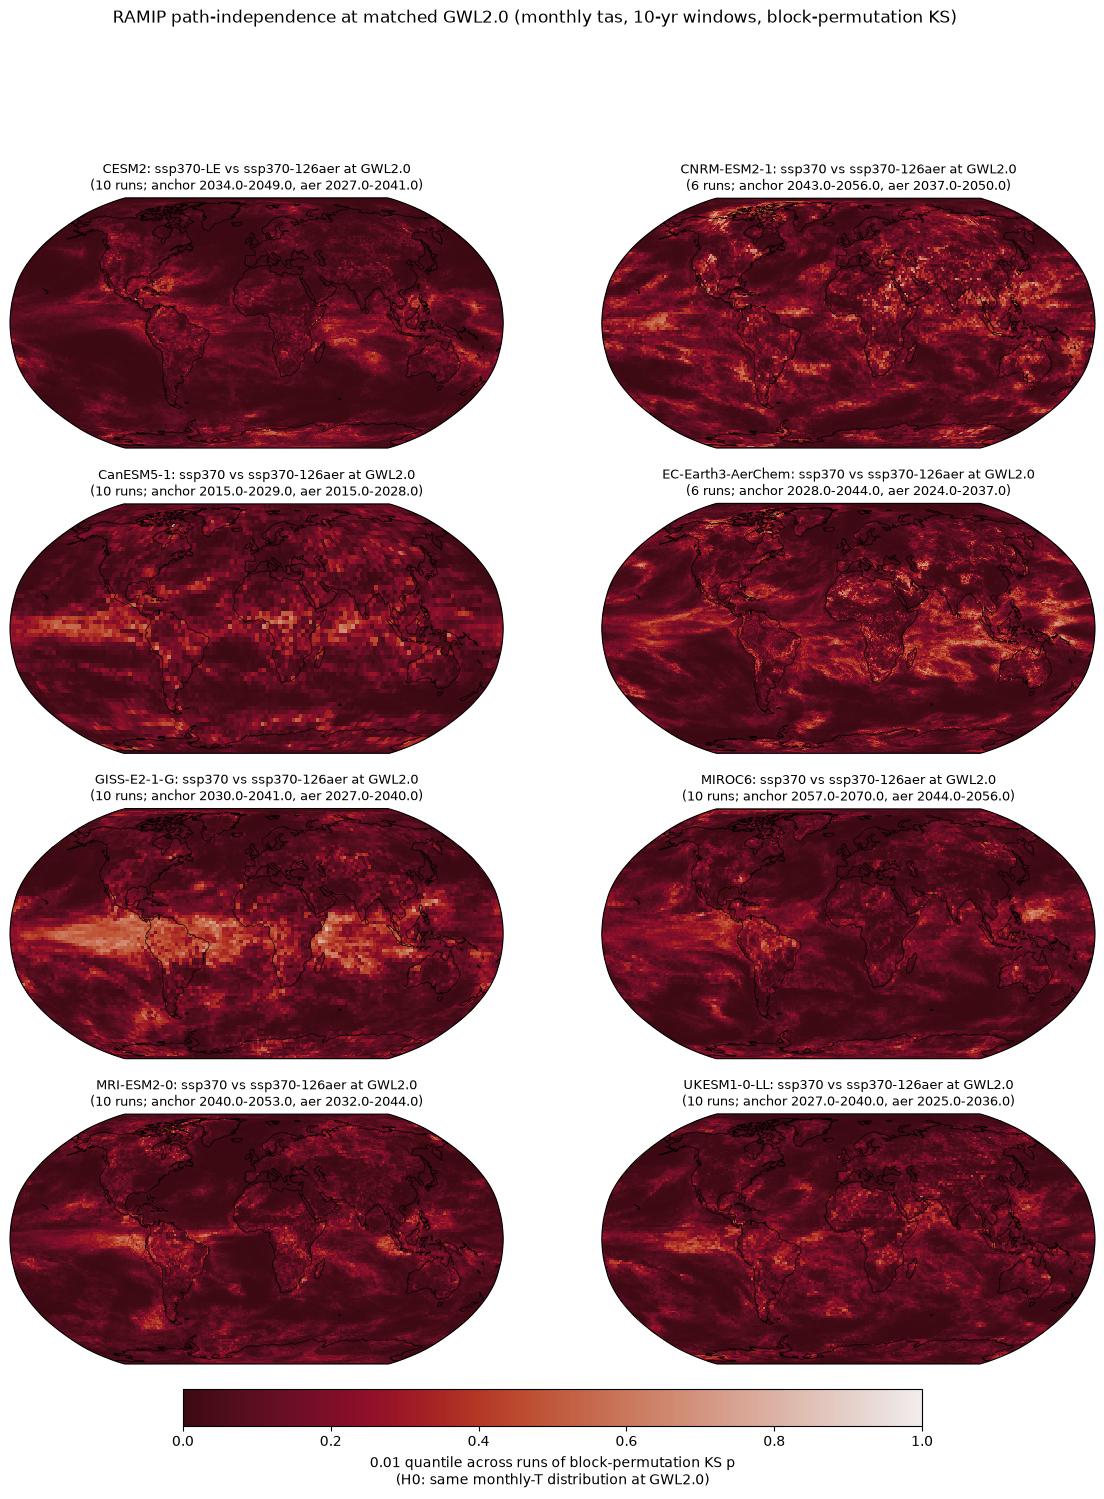

In [9]:
nm = len(GWL_MODELS)
ncol = 2
nrow = int(np.ceil(nm / ncol))
q01 = {m: results[m].p_blockperm.quantile(0.01, dim='run') for m in GWL_MODELS}

fig, axs = plt.subplots(nrow, ncol, figsize=(14, 4 * nrow),
                        subplot_kw={'projection': ccrs.Robinson()})
for ax, mod in zip(np.atleast_1d(axs).flat, GWL_MODELS):
    v = q01[mod]
    im = ax.pcolormesh(v.lon, v.lat, v, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.amp_r, vmin=0, vmax=1)
    ax.coastlines(lw=0.5)
    u = USABLE[mod]
    ax.set_title(f'{mod}: {ANCHOR[mod]} vs {OTHER} at GWL{GWL}\n'
                 f'({results[mod].sizes["run"]} runs; anchor {u.anchor_end.min()-WIN+1}-'
                 f'{u.anchor_end.max()}, aer {u.other_end.min()-WIN+1}-{u.other_end.max()})',
                 fontsize=9)
for ax in np.atleast_1d(axs).flat[nm:]:
    ax.set_visible(False)
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.03, pad=0.02,
             label=f'0.01 quantile across runs of block-permutation KS p\n'
                   f'(H0: same monthly-T distribution at GWL{GWL})')
fig.suptitle(f'RAMIP path-independence at matched GWL{GWL} (monthly tas, {WIN}-yr windows, '
             f'block-permutation KS)', y=0.995)
fig.savefig(out_dir + f'ks_blockperm_maps_ramip_gwl{GWL}.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ks_blockperm_maps_ramip_gwl{GWL}.png')

## 4. Fig-2-style regional box plots at GWL2.0

The paper's Fig-2 view, at the matched GWL: per IPCC-AR6 land region, one box per experiment of the GWL2.0-decade mean-tas anomaly, pooled over pixels in the region × runs. Anomaly removes each pixel's joint (both-experiment, all-run) mean, so only the aerosol response and internal-variability spread remain. Boxes overlapping ⇒ indistinguishable pathways in that region.

Because both experiments are now sampled at 2.0 K of global warming, a residual offset here is a genuine change in the *pattern* of warming, not a difference in its global magnitude.

In [10]:
RM_FN = f'{GWL_DIR}decadal_means.nc'


def decadal_mean(fn, y_end, win=WIN):
    ds = xr.open_zarr(fn, consolidated=False)
    yr = ds.time.dt.year
    return ds['tas'].sel(time=(yr > y_end - win) & (yr <= y_end)).mean('time').load()


means = {}
for mod in GWL_MODELS:
    cache_fn = f'{GWL_DIR}decadal_{mod}.nc'
    if os.path.exists(cache_fn):
        means[mod] = xr.open_dataarray(cache_fn).load()
        continue
    _, afns, bfns = matched_runs(mod)
    u = USABLE[mod]
    per_exp = []
    for arm, fns, col in [('anchor', afns, 'anchor_end'), ('other', bfns, 'other_end')]:
        stk = xr.concat([decadal_mean(fns[r.run], int(r[col])) for _, r in u.iterrows()],
                        dim='run').assign_coords(run=list(u.run))
        per_exp.append(stk)
    da = xr.concat(per_exp, dim='experiment').assign_coords(experiment=[ANCHOR[mod], OTHER])
    da.rename('tas_gwl_mean').to_netcdf(cache_fn)
    means[mod] = da
    print(f'{mod}: {len(u)} runs -> {cache_fn}')

CESM2: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_CESM2.nc


CNRM-ESM2-1: 6 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_CNRM-ESM2-1.nc


CanESM5-1: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_CanESM5-1.nc


EC-Earth3-AerChem: 6 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_EC-Earth3-AerChem.nc


GISS-E2-1-G: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_GISS-E2-1-G.nc


MIROC6: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_MIROC6.nc


MRI-ESM2-0: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_MRI-ESM2-0.nc


UKESM1-0-LL: 10 runs -> /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ramip_gwl/decadal_UKESM1-0-LL.nc


/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
/local/ipykernel_2309908/3577258862.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ramip_fig2_regional_boxplots_gwl2.0.png


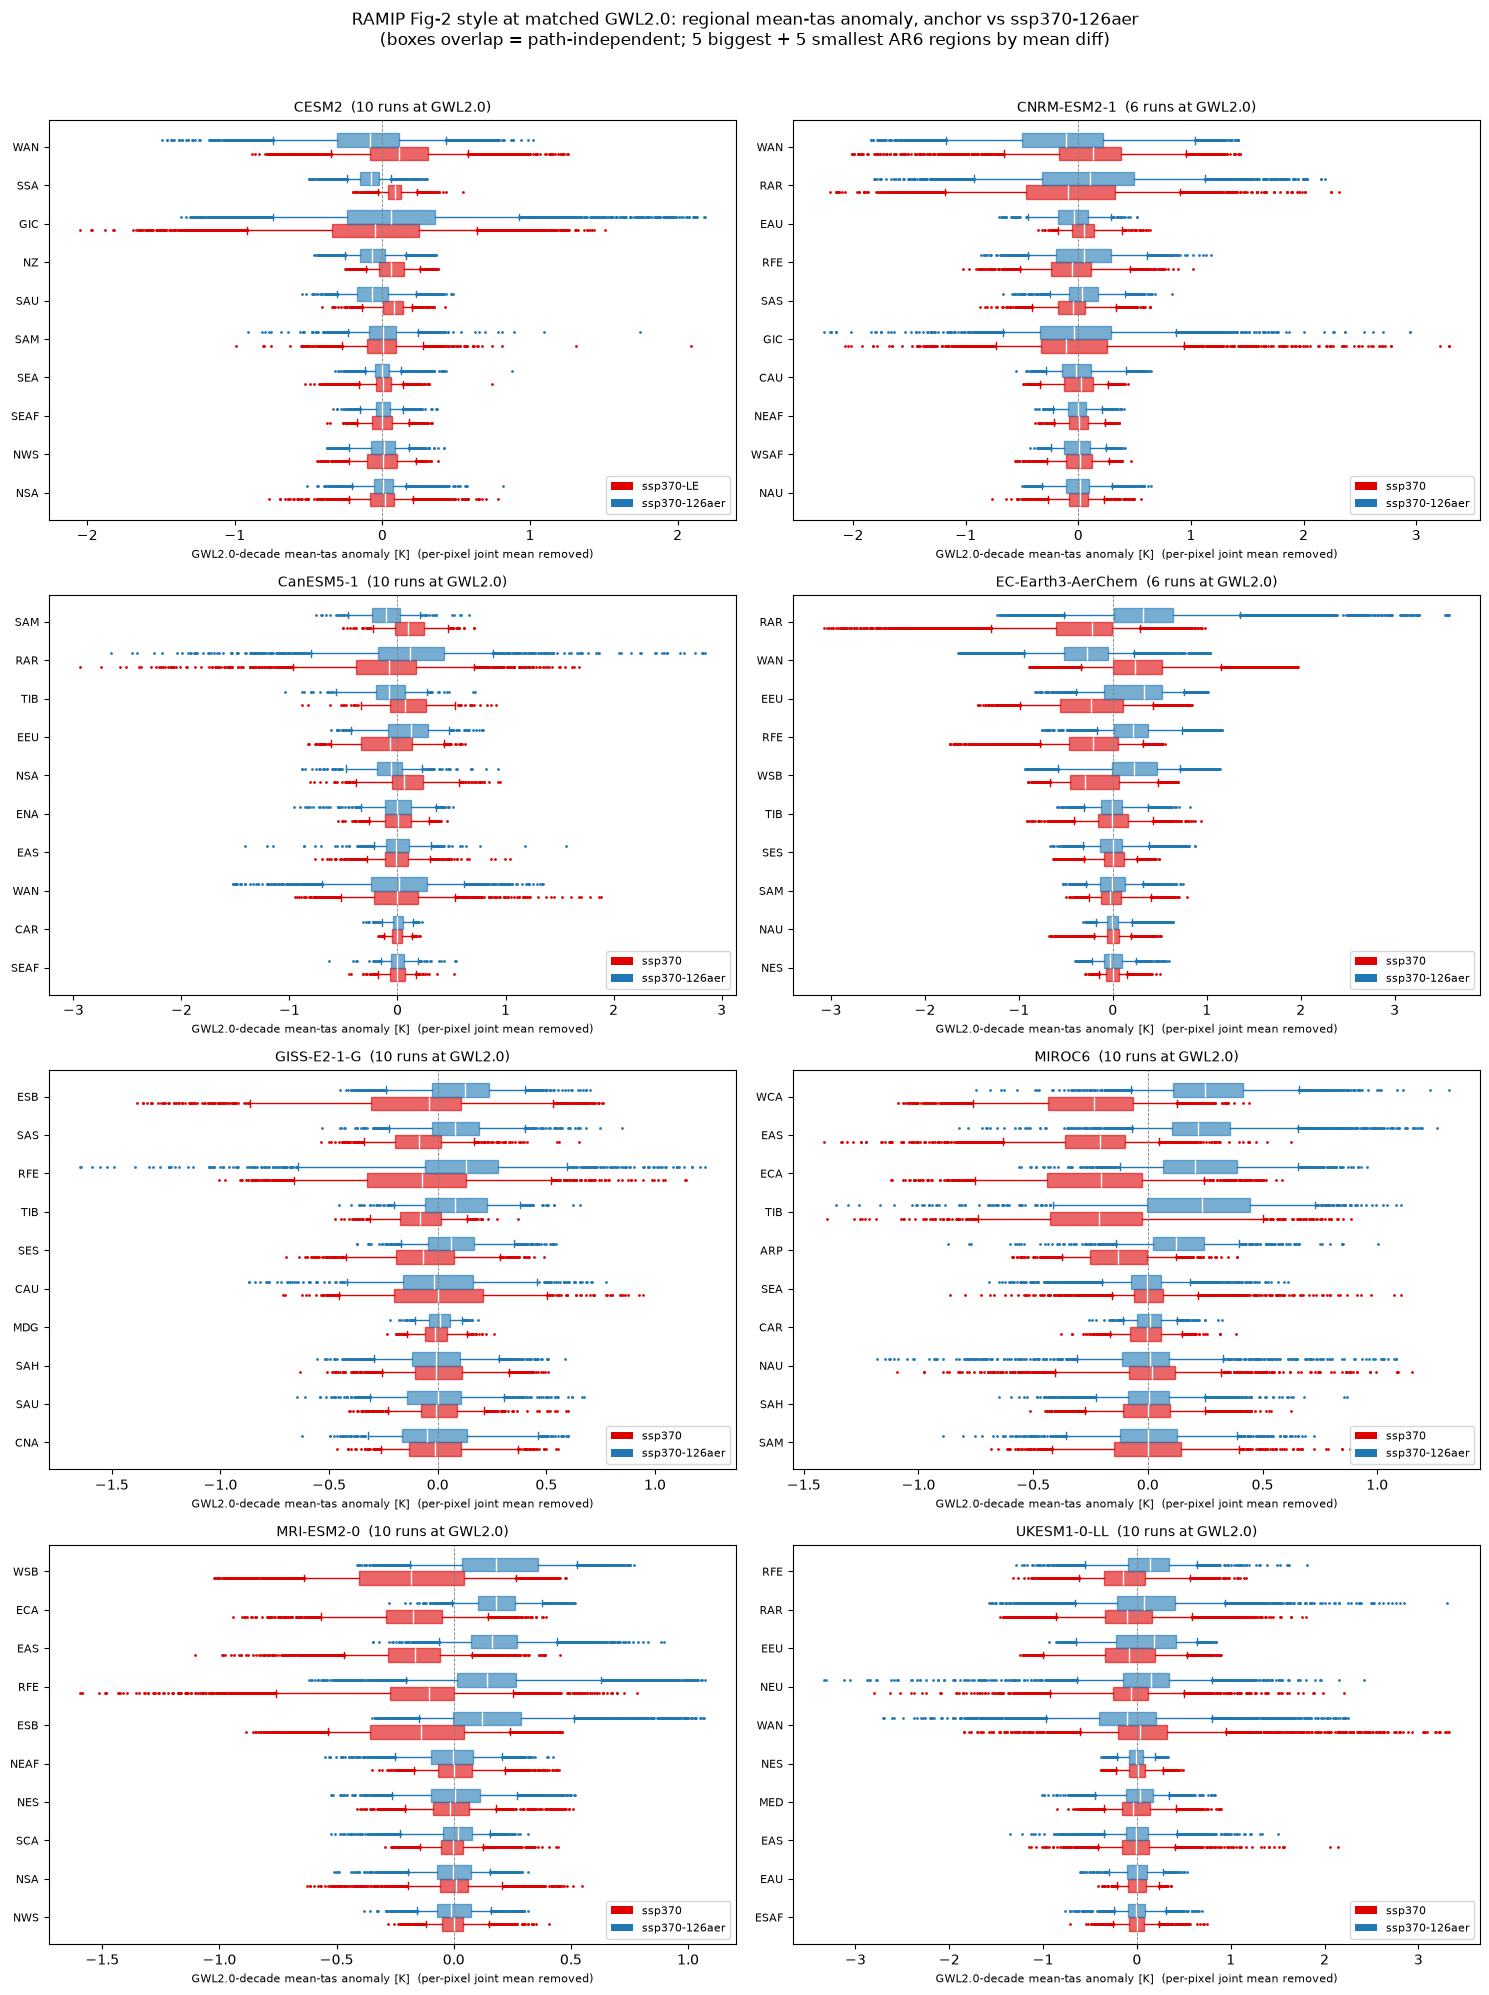

In [11]:
AR6     = regionmask.defined_regions.ar6.land
NUM2ABB = dict(zip(AR6.numbers, AR6.abbrevs))
BW, SHOW, MINPIX = 0.35, 5, 3
CLR = lambda exp: '#1f77b4' if 'aer' in exp else '#df0000'

nrow = int(np.ceil(len(GWL_MODELS) / 2))
fig, axs = plt.subplots(nrow, 2, figsize=(15, 5 * nrow))
for ax, mod in zip(np.atleast_1d(axs).flat, GWL_MODELS):
    da   = means[mod]
    anom = da - da.mean(['experiment', 'run'])
    exps = [str(e) for e in da.experiment.values]
    reg  = AR6.mask(da.lon, da.lat).values

    pooled, seps = {}, {}
    for k in np.unique(reg[np.isfinite(reg)]).astype(int):
        m2d = reg == k
        if m2d.sum() < MINPIX:
            continue
        pk = {e: anom.sel(experiment=e).values[:, m2d].ravel() for e in exps}
        pk = {e: v[np.isfinite(v)] for e, v in pk.items()}
        if any(len(v) == 0 for v in pk.values()):
            continue
        pooled[k] = pk
        seps[k]   = abs(np.mean(pk[exps[0]]) - np.mean(pk[exps[1]]))

    order = sorted(seps, key=seps.get, reverse=True)
    sel   = (order[:SHOW] + order[-SHOW:] if len(order) > 2 * SHOW else order)[::-1]

    for ri, k in enumerate(sel):
        for ei, e in enumerate(exps):
            bp = ax.boxplot(pooled[k][e], positions=[ri + (ei - 0.5) * BW], widths=BW,
                            vert=False, patch_artist=True, whis=[5, 95],
                            flierprops={'marker': '.', 'markersize': 2})
            for it in ['boxes', 'whiskers', 'fliers', 'caps']:
                plt.setp(bp[it], color=CLR(e))
            plt.setp(bp['boxes'], facecolor=CLR(e), alpha=0.6)
            plt.setp(bp['medians'], color='white')
            plt.setp(bp['fliers'], markeredgecolor=CLR(e))
    ax.axvline(0, color='0.5', lw=0.6, ls='--')
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels([NUM2ABB[k] for k in sel], fontsize=8)
    ax.set_ylim(-0.7, len(sel) - 0.3)
    ax.set_title(f'{mod}  ({da.sizes["run"]} runs at GWL{GWL})', fontsize=10)
    ax.legend(handles=[mpatches.Patch(facecolor=CLR(e), label=e) for e in exps],
              fontsize=8, loc='lower right')
    ax.set_xlabel(f'GWL{GWL}-decade mean-tas anomaly [K]  (per-pixel joint mean removed)',
                  fontsize=8)
for ax in np.atleast_1d(axs).flat[len(GWL_MODELS):]:
    ax.set_visible(False)

fig.suptitle(f'RAMIP Fig-2 style at matched GWL{GWL}: regional mean-tas anomaly, '
             f'anchor vs {OTHER}\n(boxes overlap = path-independent; '
             f'5 biggest + 5 smallest AR6 regions by mean diff)', y=0.995, fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(out_dir + f'ramip_fig2_regional_boxplots_gwl{GWL}.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ramip_fig2_regional_boxplots_gwl{GWL}.png')